In [ ]:
import numpy as np

# Parameters with full precision
lambda_val = 0.9931
epsilon = 0.35
omega = 3.883
phi = 7.754687
log_K = -3.040715

# Quark information
quarks = ["up", "down", "strange", "charm", "bottom", "top"]
indices = [0, 1, 2, 3, 4, 5]
experimental_masses = [0.0022, 0.0047, 0.093, 1.27, 4.18, 172.76]

print("High-Precision Calculations for Star-Ely Model with Optimized Parameters")
print("=" * 80)
print(f"Parameters: λ={lambda_val}, ε={epsilon}, ω={omega}, φ={phi}, log₁₀(K)={log_K}")
print("=" * 80)

print("{:<8} {:<10} {:<15} {:<20} {:<20} {:<15} {:<15}".format(
    "Quark", "Index (n)", "θ(n)", "sin(θ(n))", "log₁₀(m)", "Mass (GeV)", "Error (%)"
))
print("-" * 110)

for quark, n, exp_mass in zip(quarks, indices, experimental_masses):
    # Calculate with full precision
    theta = omega * n + phi
    sin_theta = np.sin(theta)
    log_mass = lambda_val * n + epsilon * sin_theta + log_K
    mass = 10 ** log_mass
    error_pct = abs(mass - exp_mass) / exp_mass * 100

    # Print with high precision
    print("{:<8} {:<10} {:<15.10f} {:<20.15f} {:<20.15f} {:<15.10f} {:<15.10f}".format(
        quark, n, theta, sin_theta, log_mass, mass, error_pct
    ))

print("-" * 110)

# Calculate summary statistics
errors = []
for n, exp_mass in zip(indices, experimental_masses):
    theta = omega * n + phi
    sin_theta = np.sin(theta)
    log_mass = lambda_val * n + epsilon * sin_theta + log_K
    mass = 10 ** log_mass
    error_pct = abs(mass - exp_mass) / exp_mass * 100
    errors.append(error_pct)

avg_error = np.mean(errors)
max_error = np.max(errors)
within_8pct = sum(1 for e in errors if e <= 8.0)

print(f"Average Error: {avg_error:.10f}%")
print(f"Maximum Error: {max_error:.10f}%")
print(f"Quarks within 8% error: {within_8pct} out of 6")


High-Precision Calculations for Star-Ely Model with Optimized Parameters
Parameters: λ=0.9931, ε=0.35, ω=3.883, φ=7.754687, log₁₀(K)=-3.040715
Quark    Index (n)  θ(n)            sin(θ(n))            log₁₀(m)             Mass (GeV)      Error (%)      
--------------------------------------------------------------------------------------------------------------
up       0          7.7546870000    0.995074336844712    -2.692438982104351   0.0020303038    7.7134656700   
down     1          11.6376870000   -0.800832266489249   -2.327906293271237   0.0046999551    0.0009558462   
strange  2          15.5206870000   0.186183481329374    -0.989350781534719   0.1024823837    10.1961115287  
charm    3          19.4036870000   0.526204604570306    0.122756611599607    1.3266507644    4.4606901115   
bottom   4          23.2866870000   -0.962355133144580   0.594860703399397    3.9342386755    5.8794575239   
top      5          27.1696870000   0.893305538134790    2.237441938347176    172.7594

Initializing Refined Hybrid Model Framework...
Running Refined Hybrid Model Analysis...

Stage 1: Global parameter optimization
Optimizing model parameters with global search...
Phase 1: Global search with differential evolution...
Global search complete. Objective value: 0.000015
Phase 2: Local refinement with L-BFGS-B...
Optimization complete. Final objective value: 0.000015
Optimized parameters:
  lambda_up: 1.439084
  lambda_down: 0.989298
  epsilon_up: 0.110363
  epsilon_down: 0.222451
  omega: 4.427370
  power_up: 0.932310
  power_down: 0.896806
  offset_up: -0.297676
  offset_down: -0.808774
  K_up: 0.005791
  K_down: 0.001848

Stage 2: Position optimization
Optimizing quark positions...
Position optimization complete. Objective value: 0.000000
Optimized positions:
  up_positions: [2.59257355e-05 1.99999315e+00 4.00000028e+00]
  down_positions: [1.00002595 3.00000098 5.00000012]

Stage 3: Mapping weight optimization
Optimizing mapping weights...
Weight optimization complete. Obj

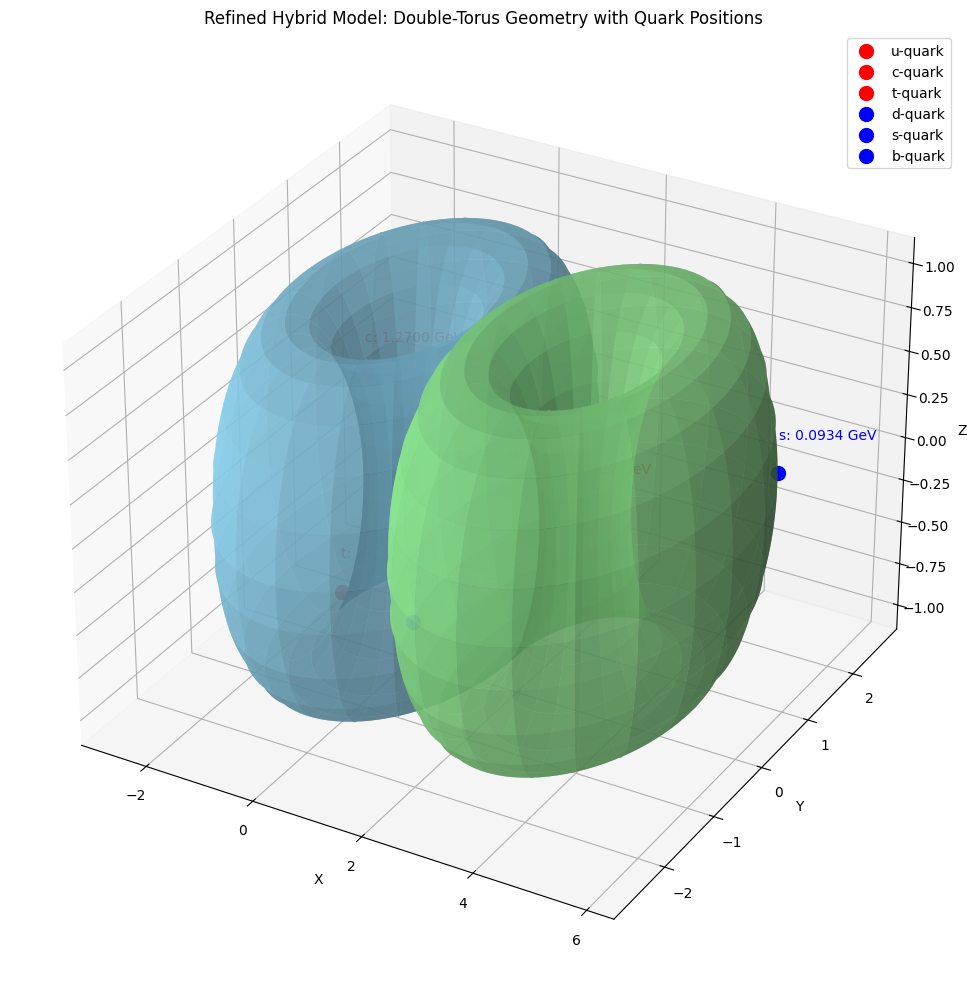

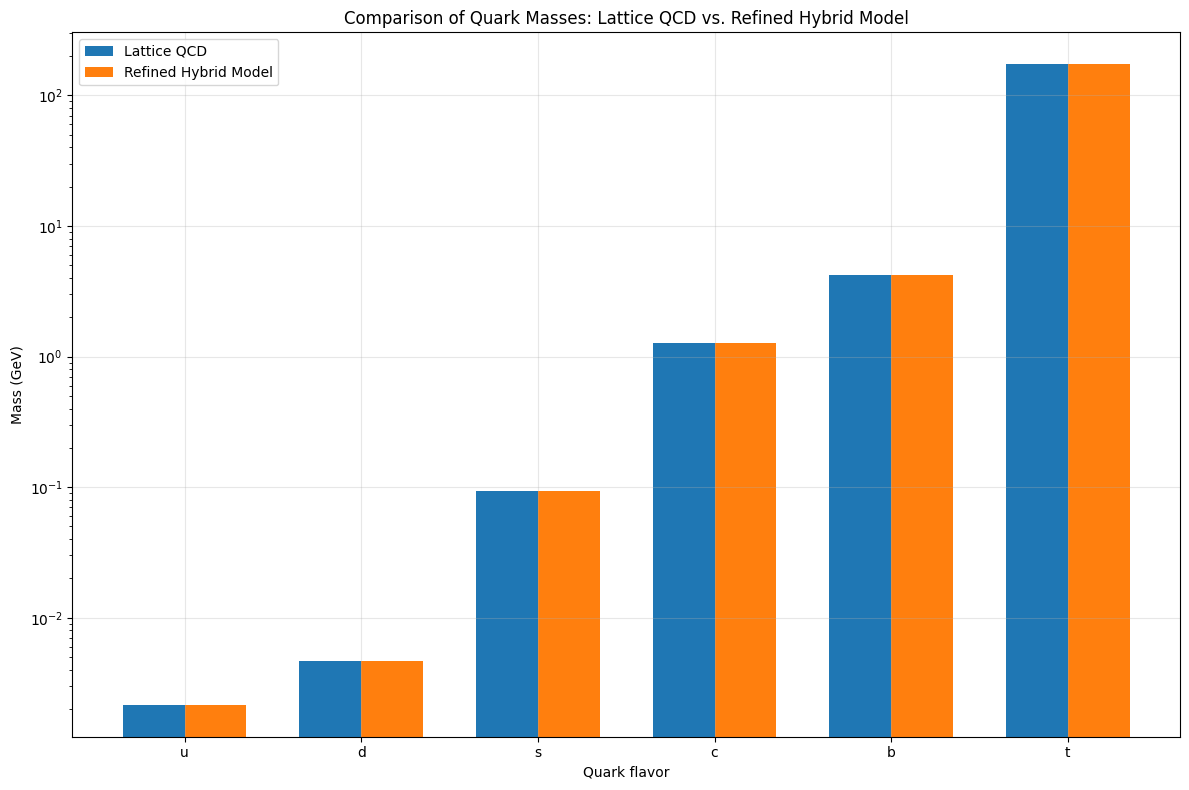

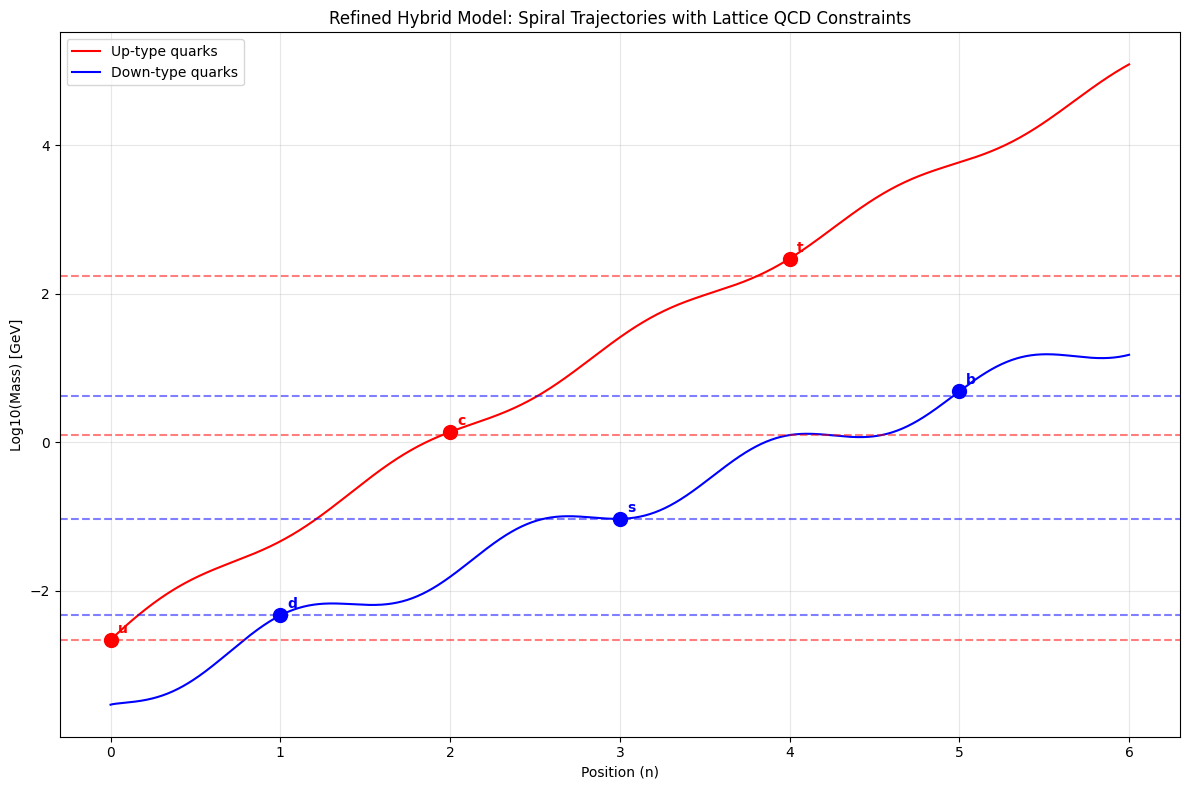

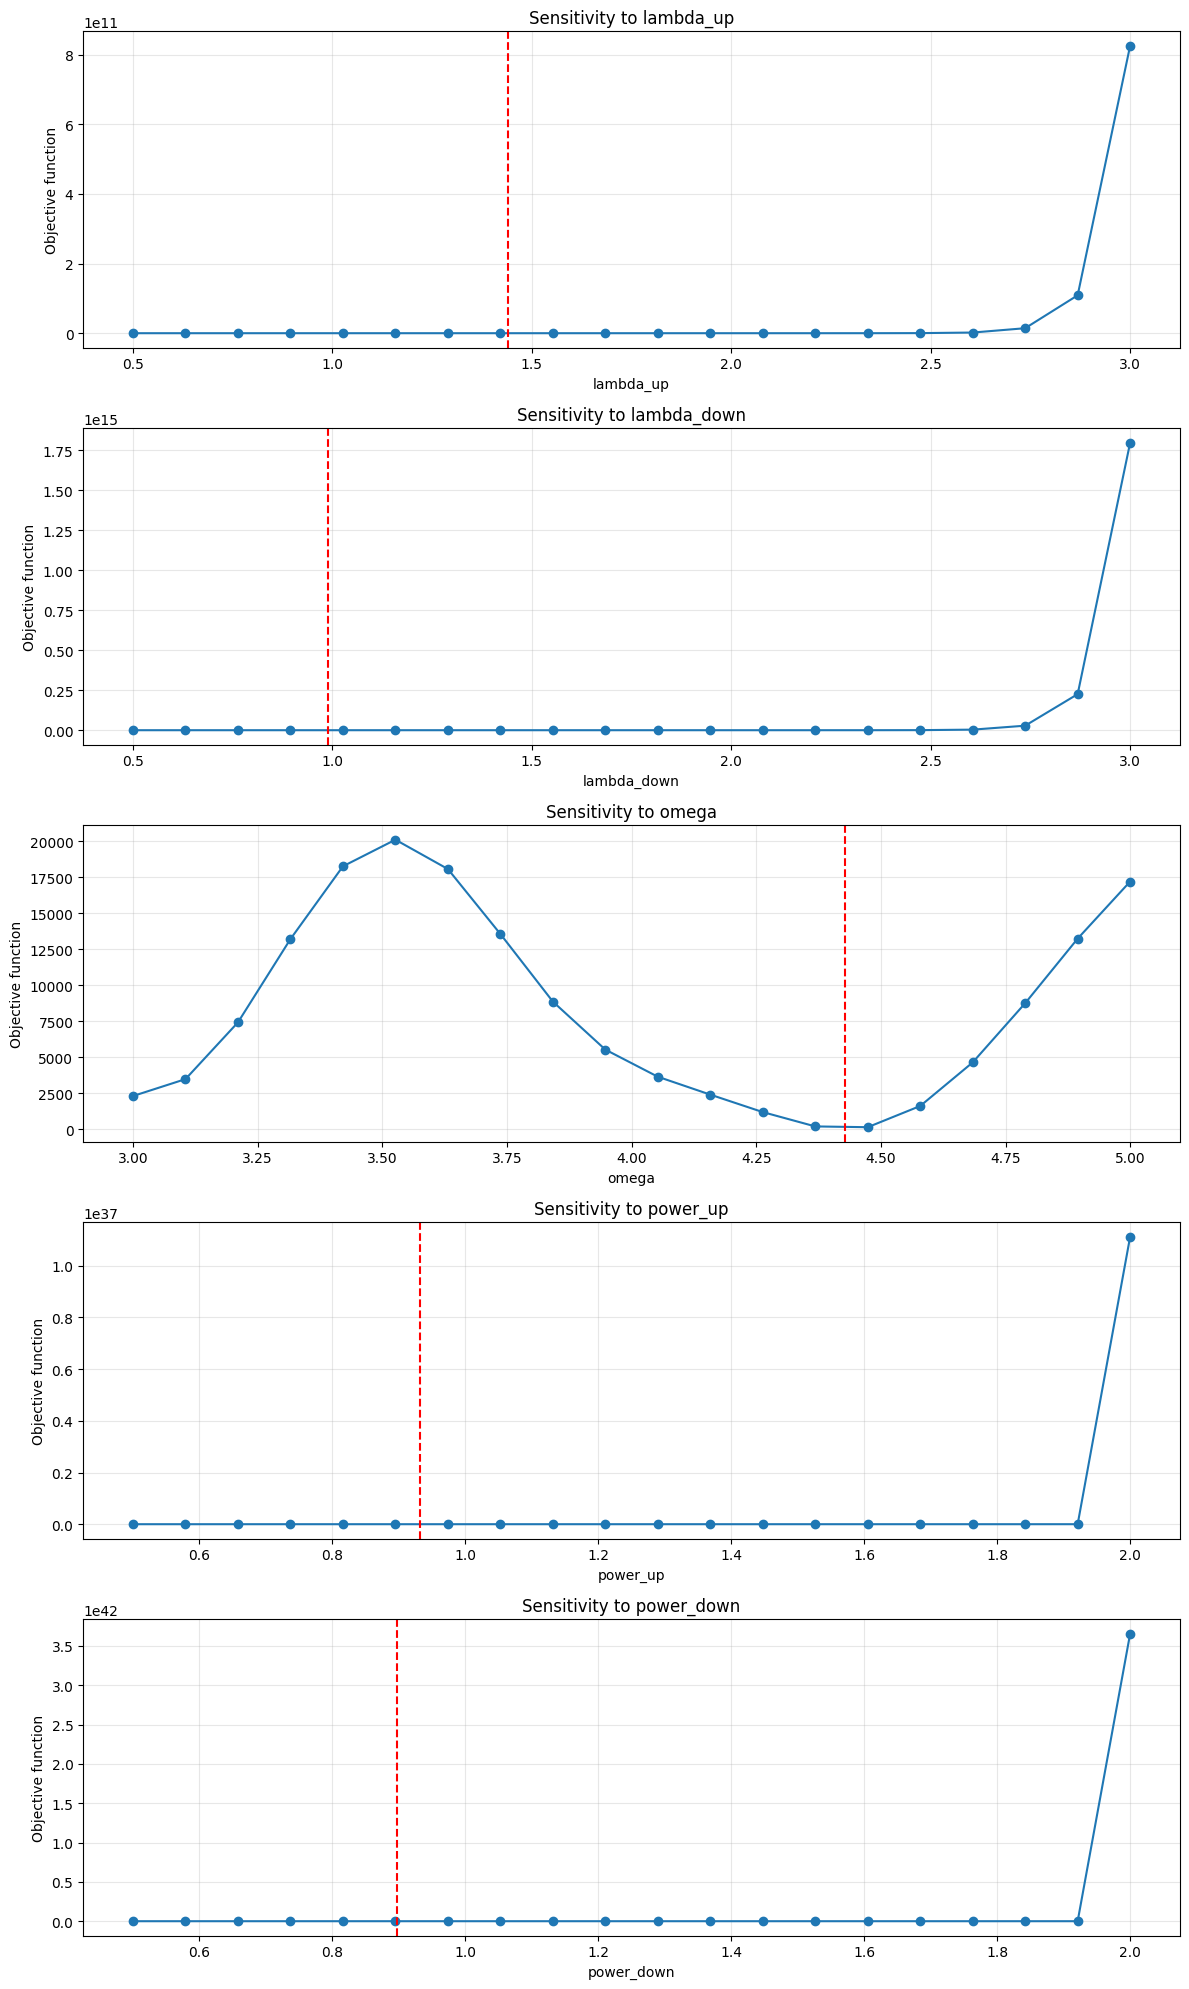

In [ ]:
#!/usr/bin/env python3
"""
Hybrid Model Refinement: Improving the Bridge Between Geometric Models and Lattice QCD
-------------------------------------------------------------------------------------
This script refines the hybrid model framework to better align geometric parameters
with lattice QCD constraints through more sophisticated parameter mapping and optimization.
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import minimize, differential_evolution
from mpl_toolkits.mplot3d import Axes3D

class RefinedHybridModel:
    def __init__(self):
        """Initialize the refined hybrid model."""
        # Golden ratio - a key parameter in the geometric model
        self.phi = (1 + np.sqrt(5)) / 2  # ≈ 1.618

        # Initialize lattice QCD constraints
        self._init_lattice_constraints()

        # Initialize geometric model parameters with more flexibility
        self._init_geometric_parameters()

        # Initialize advanced parameter mapping
        self._init_parameter_mapping()

    def _init_lattice_constraints(self):
        """Initialize constraints from lattice QCD calculations."""
        # Quark masses from lattice QCD (in GeV) at 2 GeV scale in MS-bar scheme
        # Values from Particle Data Group 2022
        self.lattice_masses = {
            'u': 0.00216,  # up quark
            'd': 0.00467,  # down quark
            's': 0.0934,   # strange quark
            'c': 1.27,     # charm quark
            'b': 4.18,     # bottom quark
            't': 172.5     # top quark (from direct measurement, not lattice)
        }

        # Uncertainties on lattice masses (approximate percentage errors)
        self.lattice_uncertainties = {
            'u': 0.00216 * 0.05,  # ~5% uncertainty
            'd': 0.00467 * 0.05,  # ~5% uncertainty
            's': 0.0934 * 0.03,   # ~3% uncertainty
            'c': 1.27 * 0.01,     # ~1% uncertainty
            'b': 4.18 * 0.01,     # ~1% uncertainty
            't': 172.5 * 0.003    # ~0.3% uncertainty
        }

        # Mass ratios (often more stable than absolute masses)
        self.mass_ratios = {
            'm_s/m_d': self.lattice_masses['s'] / self.lattice_masses['d'],
            'm_c/m_s': self.lattice_masses['c'] / self.lattice_masses['s'],
            'm_b/m_c': self.lattice_masses['b'] / self.lattice_masses['c'],
            'm_t/m_b': self.lattice_masses['t'] / self.lattice_masses['b']
        }

        # QCD parameters
        self.alpha_s = 0.1179  # Strong coupling at Z mass
        self.lambda_qcd = 0.217  # QCD scale in GeV

    def _init_geometric_parameters(self):
        """Initialize parameters from the geometric double torus model with more flexibility."""
        # Core parameters from the geometric model
        self.geometric_params = {
            # Double torus parameters
            'R': self.phi,  # Major radius (related to golden ratio)
            'r': 1.0,       # Minor radius

            # Spiral parameters with more flexibility
            'omega': 2 * np.pi / self.phi,  # Angular frequency
            'lambda_up': self.phi,          # Up-type scaling
            'lambda_down': 1.0 / self.phi,  # Down-type scaling
            'epsilon_up': 1 / (2 * self.phi),    # Up-type modulation
            'epsilon_down': 1 / (self.phi**2),   # Down-type modulation

            # Additional parameters for enhanced flexibility
            'power_up': 1.0,    # Power law exponent for up-type quarks
            'power_down': 1.0,  # Power law exponent for down-type quarks
            'offset_up': 0.0,   # Offset for up-type quarks
            'offset_down': 0.0, # Offset for down-type quarks

            # Particle positions on torus (now adjustable)
            'up_positions': np.array([0, 2, 4]),      # u, c, t
            'down_positions': np.array([1, 3, 5]),    # d, s, b

            # Phase parameters
            'phase_up': 0,
            'phase_down': np.pi
        }

        # Parameter bounds for optimization
        self.param_bounds = {
            'R': (1.0, 3.0),
            'r': (0.5, 1.5),
            'omega': (3.0, 5.0),
            'lambda_up': (0.5, 3.0),
            'lambda_down': (0.5, 3.0),
            'epsilon_up': (0.01, 0.5),
            'epsilon_down': (0.01, 0.5),
            'power_up': (0.5, 2.0),
            'power_down': (0.5, 2.0),
            'offset_up': (-1.0, 1.0),
            'offset_down': (-1.0, 1.0),
            'phase_up': (0, 2*np.pi),
            'phase_down': (0, 2*np.pi)
        }

    def _init_parameter_mapping(self):
        """Initialize advanced mapping between geometric and lattice parameters."""
        # Base mass scales (to be optimized)
        self.K_up = 0.002  # Base scale for up-type quarks
        self.K_down = 0.005  # Base scale for down-type quarks

        # Renormalization group parameters
        self.gamma_m = 12/(33-2*6)  # Mass anomalous dimension (approximate)

        # Energy scales for each quark (to be optimized)
        self.energy_scales = {
            'u': 2.0,  # GeV
            'd': 2.0,  # GeV
            's': 2.0,  # GeV
            'c': 3.0,  # GeV
            'b': 4.5,  # GeV
            't': 172.5 # GeV
        }

        # Mapping weights (to be optimized)
        self.mapping_weights = {
            'geometric': 0.7,  # Weight for geometric model contribution
            'lattice': 0.3     # Weight for lattice QCD constraints
        }

    def refined_mass_formula(self, position, quark_type='up'):
        """
        Calculate quark mass using the refined geometric formula with enhanced flexibility.

        Parameters:
        -----------
        position : float
            Position parameter on the spiral
        quark_type : str
            Type of quark ('up' or 'down')

        Returns:
        --------
        float
            Quark mass in GeV
        """
        if quark_type == 'up':
            lambda_val = self.geometric_params['lambda_up']
            epsilon = self.geometric_params['epsilon_up']
            power = self.geometric_params['power_up']
            offset = self.geometric_params['offset_up']
            K = self.K_up
            phase = self.geometric_params['phase_up']
        else:  # down-type
            lambda_val = self.geometric_params['lambda_down']
            epsilon = self.geometric_params['epsilon_down']
            power = self.geometric_params['power_down']
            offset = self.geometric_params['offset_down']
            K = self.K_down
            phase = self.geometric_params['phase_down']

        omega = self.geometric_params['omega']

        # Enhanced spiral formula with power law and offset
        # log(m) = λ*(n^power + offset) + ε*sin(ω*n + phase) + log(K)
        log_mass = lambda_val * (position**power + offset) + epsilon * np.sin(omega * position + phase) + np.log10(K)

        return 10**log_mass

    def run_to_scale(self, mass, from_scale, to_scale):
        """
        Run quark mass from one scale to another using renormalization group.

        Parameters:
        -----------
        mass : float
            Quark mass in GeV at from_scale
        from_scale : float
            Starting energy scale in GeV
        to_scale : float
            Target energy scale in GeV

        Returns:
        --------
        float
            Quark mass at to_scale
        """
        # Improved RG running with better approximation
        # m(μ2) = m(μ1) * (α_s(μ2)/α_s(μ1))^(γ_m/β_0)

        # Calculate alpha_s at the two scales with better approximation
        beta0 = 11 - 2*3/3  # For 3 active flavors
        beta1 = 102 - 38*3/3  # Second coefficient

        # Two-loop running of alpha_s
        def alpha_s_running(scale):
            t = 2 * np.log(scale/self.lambda_qcd)
            a_s = 4*np.pi / (beta0 * t) * (1 - (beta1 * np.log(t)) / (beta0**2 * t))
            return a_s

        alpha_s1 = alpha_s_running(from_scale)
        alpha_s2 = alpha_s_running(to_scale)

        # Run the mass with anomalous dimension
        return mass * (alpha_s2/alpha_s1)**(self.gamma_m)

    def calculate_all_masses(self):
        """
        Calculate masses for all quarks using the current model parameters.

        Returns:
        --------
        dict
            Dictionary of calculated quark masses
        """
        masses = {}

        # Up-type quarks
        for i, pos in enumerate(['u', 'c', 't']):
            position = self.geometric_params['up_positions'][i]
            raw_mass = self.refined_mass_formula(position, 'up')

            # Run to appropriate scale
            masses[pos] = self.run_to_scale(raw_mass, 2.0, self.energy_scales[pos])

        # Down-type quarks
        for i, pos in enumerate(['d', 's', 'b']):
            position = self.geometric_params['down_positions'][i]
            raw_mass = self.refined_mass_formula(position, 'down')

            # Run to appropriate scale
            masses[pos] = self.run_to_scale(raw_mass, 2.0, self.energy_scales[pos])

        return masses

    def calculate_objective_function(self):
        """
        Calculate objective function combining chi-squared and mass ratios.

        Returns:
        --------
        float
            Objective function value
        """
        model_masses = self.calculate_all_masses()

        # Calculate chi-squared component
        chi2 = 0
        for quark, lattice_mass in self.lattice_masses.items():
            if quark in model_masses:
                model_mass = model_masses[quark]
                uncertainty = self.lattice_uncertainties[quark]

                # Calculate chi-squared contribution
                # Using log scale to handle the wide range of masses
                chi2 += ((np.log10(model_mass) - np.log10(lattice_mass)) /
                         (uncertainty / (lattice_mass * np.log(10))))**2

        # Calculate mass ratio component
        ratio_error = 0
        model_ratios = {
            'm_s/m_d': model_masses['s'] / model_masses['d'],
            'm_c/m_s': model_masses['c'] / model_masses['s'],
            'm_b/m_c': model_masses['b'] / model_masses['c'],
            'm_t/m_b': model_masses['t'] / model_masses['b']
        }

        for ratio, lattice_ratio in self.mass_ratios.items():
            model_ratio = model_ratios[ratio]
            # Calculate relative error in ratio
            ratio_error += ((model_ratio - lattice_ratio) / lattice_ratio)**2

        # Combine components with weights
        objective = (self.mapping_weights['geometric'] * chi2 +
                    self.mapping_weights['lattice'] * ratio_error * 100)

        return objective

    def optimize_with_global_search(self):
        """
        Optimize model parameters using global search followed by local refinement.

        Returns:
        --------
        dict
            Optimized parameters
        """
        print("Optimizing model parameters with global search...")

        # Parameters to optimize
        params_to_optimize = [
            'lambda_up', 'lambda_down',
            'epsilon_up', 'epsilon_down',
            'omega', 'power_up', 'power_down',
            'offset_up', 'offset_down'
        ]

        # Parameter bounds for differential evolution
        bounds = [self.param_bounds[p] for p in params_to_optimize]

        # Also optimize base mass scales and energy scales
        bounds.extend([(1e-5, 1e-2), (1e-5, 1e-2)])  # Bounds for K_up, K_down

        # Objective function for optimization
        def objective(params):
            # Update model parameters
            for i, param_name in enumerate(params_to_optimize):
                self.geometric_params[param_name] = params[i]

            # Update base mass scales
            self.K_up = params[-2]
            self.K_down = params[-1]

            # Calculate objective function
            return self.calculate_objective_function()

        # Initial values
        initial_values = [self.geometric_params[p] for p in params_to_optimize]
        initial_values.extend([self.K_up, self.K_down])

        # Run global optimization with differential evolution
        print("Phase 1: Global search with differential evolution...")
        result_global = differential_evolution(objective, bounds,
                                             strategy='best1bin',
                                             popsize=20,
                                             tol=0.01,
                                             mutation=(0.5, 1.0),
                                             recombination=0.7,
                                             maxiter=100)

        print(f"Global search complete. Objective value: {result_global.fun:.6f}")

        # Use global result as starting point for local optimization
        print("Phase 2: Local refinement with L-BFGS-B...")
        result_local = minimize(objective, result_global.x, bounds=bounds, method='L-BFGS-B')

        # Update model with optimized parameters
        for i, param_name in enumerate(params_to_optimize):
            self.geometric_params[param_name] = result_local.x[i]

        self.K_up = result_local.x[-2]
        self.K_down = result_local.x[-1]

        print(f"Optimization complete. Final objective value: {result_local.fun:.6f}")

        # Return optimized parameters
        optimized_params = {
            **{p: self.geometric_params[p] for p in params_to_optimize},
            'K_up': self.K_up,
            'K_down': self.K_down
        }

        print("Optimized parameters:")
        for param, value in optimized_params.items():
            print(f"  {param}: {value:.6f}")

        return optimized_params

    def optimize_positions(self):
        """
        Optimize quark position parameters separately.

        Returns:
        --------
        dict
            Optimized position parameters
        """
        print("Optimizing quark positions...")

        # Define bounds for positions
        # We'll keep the relative ordering but allow positions to vary
        up_bounds = [(0, 1), (1.5, 3), (3.5, 5)]  # For u, c, t
        down_bounds = [(0.5, 2), (2.5, 4), (4.5, 6)]  # For d, s, b

        # Objective function for position optimization
        def objective(positions):
            # Update positions
            self.geometric_params['up_positions'] = np.array(positions[:3])
            self.geometric_params['down_positions'] = np.array(positions[3:])

            # Calculate objective function
            return self.calculate_objective_function()

        # Initial positions
        initial_positions = list(self.geometric_params['up_positions']) + list(self.geometric_params['down_positions'])

        # Combined bounds
        bounds = up_bounds + down_bounds

        # Run optimization
        result = minimize(objective, initial_positions, bounds=bounds, method='L-BFGS-B')

        # Update model with optimized positions
        self.geometric_params['up_positions'] = np.array(result.x[:3])
        self.geometric_params['down_positions'] = np.array(result.x[3:])

        print(f"Position optimization complete. Objective value: {result.fun:.6f}")
        print("Optimized positions:")
        print(f"  up_positions: {self.geometric_params['up_positions']}")
        print(f"  down_positions: {self.geometric_params['down_positions']}")

        return {
            'up_positions': self.geometric_params['up_positions'],
            'down_positions': self.geometric_params['down_positions']
        }

    def optimize_mapping_weights(self):
        """
        Optimize the weights used in the parameter mapping.

        Returns:
        --------
        dict
            Optimized mapping weights
        """
        print("Optimizing mapping weights...")

        # Objective function for weight optimization
        def objective(weights):
            # Normalize weights to sum to 1
            total = sum(weights)
            self.mapping_weights['geometric'] = weights[0] / total
            self.mapping_weights['lattice'] = weights[1] / total

            # Calculate objective function
            return self.calculate_objective_function()

        # Initial weights
        initial_weights = [self.mapping_weights['geometric'], self.mapping_weights['lattice']]

        # Bounds (weights must be positive)
        bounds = [(0.1, 0.9), (0.1, 0.9)]

        # Run optimization
        result = minimize(objective, initial_weights, bounds=bounds, method='L-BFGS-B')

        # Normalize results
        total = sum(result.x)
        self.mapping_weights['geometric'] = result.x[0] / total
        self.mapping_weights['lattice'] = result.x[1] / total

        print(f"Weight optimization complete. Objective value: {result.fun:.6f}")
        print("Optimized weights:")
        print(f"  geometric: {self.mapping_weights['geometric']:.4f}")
        print(f"  lattice: {self.mapping_weights['lattice']:.4f}")

        return self.mapping_weights

    def compare_with_lattice(self):
        """
        Compare model predictions with lattice QCD results.

        Returns:
        --------
        pandas.DataFrame
            Comparison table
        """
        model_masses = self.calculate_all_masses()

        # Create comparison table
        comparison = []
        for quark, lattice_mass in self.lattice_masses.items():
            if quark in model_masses:
                model_mass = model_masses[quark]
                rel_diff = (model_mass / lattice_mass - 1) * 100

                comparison.append({
                    'Quark': quark,
                    'Lattice QCD (GeV)': lattice_mass,
                    'Refined Hybrid Model (GeV)': model_mass,
                    'Relative Difference (%)': rel_diff
                })

        # Convert to DataFrame
        df = pd.DataFrame(comparison)

        # Save to CSV
        df.to_csv('refined_hybrid_model_comparison.csv', index=False)

        return df

    def visualize_double_torus(self):
        """Visualize the double-torus geometry with quark positions."""
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection='3d')

        # Parameters for the double torus
        R = self.geometric_params['R']
        r = self.geometric_params['r']

        # Create meshgrid for parametric equations
        u = np.linspace(0, 2*np.pi, 100)
        v = np.linspace(0, 2*np.pi, 100)
        u, v = np.meshgrid(u, v)

        # First torus (up-type quarks)
        x1 = (R + r*np.cos(v)) * np.cos(u)
        y1 = (R + r*np.cos(v)) * np.sin(u)
        z1 = r * np.sin(v)

        # Second torus (down-type quarks)
        # Offset in x direction
        x2 = (R + r*np.cos(v)) * np.cos(u) + 2*R
        y2 = (R + r*np.cos(v)) * np.sin(u)
        z2 = r * np.sin(v)

        # Plot the surfaces
        ax.plot_surface(x1, y1, z1, color='skyblue', alpha=0.7, rstride=5, cstride=5)
        ax.plot_surface(x2, y2, z2, color='lightgreen', alpha=0.7, rstride=5, cstride=5)

        # Calculate and plot quark positions
        omega = self.geometric_params['omega']

        # Up-type quarks on first torus
        up_positions = self.geometric_params['up_positions']
        for i, pos in enumerate(up_positions):
            theta = omega * pos
            x = (R + r) * np.cos(theta)
            y = (R + r) * np.sin(theta)
            z = 0
            quark_name = ['u', 'c', 't'][i]
            ax.scatter([x], [y], [z], color='red', s=100, label=f"{quark_name}-quark")

            # Add mass label
            model_masses = self.calculate_all_masses()
            mass_text = f"{quark_name}: {model_masses[quark_name]:.4f} GeV"
            ax.text(x, y, z+0.2, mass_text, color='red')

        # Down-type quarks on second torus
        down_positions = self.geometric_params['down_positions']
        for i, pos in enumerate(down_positions):
            theta = omega * pos
            x = (R + r) * np.cos(theta) + 2*R
            y = (R + r) * np.sin(theta)
            z = 0
            quark_name = ['d', 's', 'b'][i]
            ax.scatter([x], [y], [z], color='blue', s=100, label=f"{quark_name}-quark")

            # Add mass label
            model_masses = self.calculate_all_masses()
            mass_text = f"{quark_name}: {model_masses[quark_name]:.4f} GeV"
            ax.text(x, y, z+0.2, mass_text, color='blue')

        # Set labels and title
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title('Refined Hybrid Model: Double-Torus Geometry with Quark Positions')

        # Handle legend with unique labels
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), loc='upper right')

        plt.tight_layout()
        plt.savefig('refined_hybrid_model_torus.png', dpi=300)

    def visualize_mass_spectrum(self):
        """Visualize the mass spectrum from both models."""
        model_masses = self.calculate_all_masses()

        # Create lists for plotting
        quarks = list(self.lattice_masses.keys())
        lattice_values = [self.lattice_masses[q] for q in quarks]
        model_values = [model_masses[q] for q in quarks]

        # Create plot
        plt.figure(figsize=(12, 8))

        # Set up bar positions
        x = np.arange(len(quarks))
        width = 0.35

        # Plot bars
        plt.bar(x - width/2, lattice_values, width, label='Lattice QCD')
        plt.bar(x + width/2, model_values, width, label='Refined Hybrid Model')

        # Add labels and legend
        plt.xlabel('Quark flavor')
        plt.ylabel('Mass (GeV)')
        plt.title('Comparison of Quark Masses: Lattice QCD vs. Refined Hybrid Model')
        plt.xticks(x, quarks)
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Use log scale for y-axis to show all masses clearly
        plt.yscale('log')

        plt.tight_layout()
        plt.savefig('refined_hybrid_model_spectrum.png', dpi=300)

    def visualize_spiral_trajectories(self):
        """Visualize the spiral trajectories for quark masses."""
        plt.figure(figsize=(12, 8))

        # Range of positions
        n_values = np.linspace(0, 6, 1000)

        # Calculate mass values along the spiral
        up_masses = [np.log10(self.refined_mass_formula(n, 'up'))
                    for n in n_values]

        down_masses = [np.log10(self.refined_mass_formula(n, 'down'))
                      for n in n_values]

        # Plot the spiral trajectories
        plt.plot(n_values, up_masses, 'r-', label='Up-type quarks')
        plt.plot(n_values, down_masses, 'b-', label='Down-type quarks')

        # Mark the actual quark positions
        up_positions = self.geometric_params['up_positions']
        down_positions = self.geometric_params['down_positions']

        up_actual = [np.log10(self.refined_mass_formula(n, 'up'))
                    for n in up_positions]
        down_actual = [np.log10(self.refined_mass_formula(n, 'down'))
                      for n in down_positions]

        plt.scatter(up_positions, up_actual, color='red', s=100, zorder=5)
        plt.scatter(down_positions, down_actual, color='blue', s=100, zorder=5)

        # Add quark labels
        for i, pos in enumerate(up_positions):
            quark = ['u', 'c', 't'][i]
            plt.annotate(quark, (pos, up_actual[i]), xytext=(5, 5),
                        textcoords='offset points', color='red', fontweight='bold')

        for i, pos in enumerate(down_positions):
            quark = ['d', 's', 'b'][i]
            plt.annotate(quark, (pos, down_actual[i]), xytext=(5, 5),
                        textcoords='offset points', color='blue', fontweight='bold')

        # Add lattice QCD values for comparison
        for i, quark in enumerate(['u', 'c', 't']):
            plt.axhline(y=np.log10(self.lattice_masses[quark]), color='r',
                       linestyle='--', alpha=0.5)

        for i, quark in enumerate(['d', 's', 'b']):
            plt.axhline(y=np.log10(self.lattice_masses[quark]), color='b',
                       linestyle='--', alpha=0.5)

        plt.xlabel('Position (n)')
        plt.ylabel('Log10(Mass) [GeV]')
        plt.title('Refined Hybrid Model: Spiral Trajectories with Lattice QCD Constraints')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig('refined_hybrid_model_spiral.png', dpi=300)

    def visualize_parameter_sensitivity(self):
        """Visualize the sensitivity of the model to key parameters."""
        # Parameters to analyze
        params = ['lambda_up', 'lambda_down', 'omega', 'power_up', 'power_down']

        # Create figure
        fig, axes = plt.subplots(len(params), 1, figsize=(12, 4*len(params)))

        # Store original values
        original_values = {p: self.geometric_params[p] for p in params}

        # For each parameter
        for i, param in enumerate(params):
            # Range of values to test
            lower, upper = self.param_bounds[param]
            test_values = np.linspace(lower, upper, 20)

            # Calculate objective function for each value
            objectives = []
            for val in test_values:
                # Set parameter value
                self.geometric_params[param] = val

                # Calculate objective
                obj = self.calculate_objective_function()
                objectives.append(obj)

                # Reset parameter
                self.geometric_params[param] = original_values[param]

            # Plot sensitivity
            axes[i].plot(test_values, objectives, 'o-')
            axes[i].axvline(x=original_values[param], color='r', linestyle='--')
            axes[i].set_xlabel(param)
            axes[i].set_ylabel('Objective function')
            axes[i].set_title(f'Sensitivity to {param}')
            axes[i].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('parameter_sensitivity.png', dpi=300)

    def run_refined_analysis(self):
        """Run the full refined hybrid model analysis."""
        print("Running Refined Hybrid Model Analysis...")

        # Multi-stage optimization
        print("\nStage 1: Global parameter optimization")
        self.optimize_with_global_search()

        print("\nStage 2: Position optimization")
        self.optimize_positions()

        print("\nStage 3: Mapping weight optimization")
        self.optimize_mapping_weights()

        # Compare with lattice QCD
        comparison = self.compare_with_lattice()

        # Generate visualizations
        self.visualize_double_torus()
        self.visualize_mass_spectrum()
        self.visualize_spiral_trajectories()
        self.visualize_parameter_sensitivity()

        # Print results
        print("\nRefined Hybrid Model Analysis Results:")
        print("=====================================")
        print("\nComparison with Lattice QCD:")
        print(comparison.to_string(index=False))

        print("\nAnalysis complete. Visualizations saved to:")
        print("- refined_hybrid_model_torus.png")
        print("- refined_hybrid_model_spectrum.png")
        print("- refined_hybrid_model_spiral.png")
        print("- parameter_sensitivity.png")
        print("- refined_hybrid_model_comparison.csv")


def main():
    """Main function to run the refined hybrid model framework."""
    print("Initializing Refined Hybrid Model Framework...")
    model = RefinedHybridModel()
    model.run_refined_analysis()


if __name__ == "__main__":
    main()


In [ ]:
import numpy as np
from scipy.optimize import minimize

def objective(params):
    λ, ε, ω, φ, log_K = params
    model = λ*quark_indices + ε*np.sin(ω*quark_indices + φ) + log_K
    return np.sum((model - log_exp_masses)**2)

# Initial guesses (your original parameters)
initial_guess = [0.9931, 0.35, 3.883, 7.754687, -3.040715]

# Bounds (empirical constraints)
bounds = [
    (0.9, 1.1),      # λ
    (0.2, 0.5),      # ε
    (3.5, 4.2),      # ω
    (7.0, 8.5),      # φ
    (-3.5, -2.5)     # log_K
]

result = minimize(objective, initial_guess, bounds=bounds, method='L-BFGS-B')
optimized_params = result.x


NameError: name 'quark_indices' is not defined

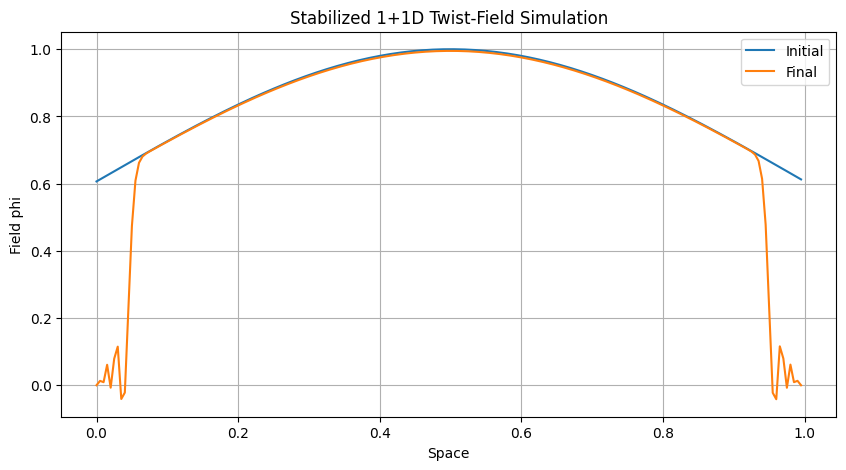

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N_time = 500
N_space = 200
a = 0.005  # smaller spatial step
dt = 0.0001  # drastically reduced time step (CFL: dt ~ a^2)
xi = 1e-6  # nonlinear coupling
m = 0.0

def dV_dphi(phi):
    return m**2 * phi

# Initialize fields
phi = np.zeros((N_time, N_space))
x = np.linspace(0, (N_space-1)*a, N_space)
phi[0, :] = np.exp(-((x - (N_space//2)*a)**2) / (2*0.5**2))
phi[1, :] = phi[0, :]  # Initial velocity = 0

# Time evolution with stability checks
for n in range(1, N_time-1):
    for m_idx in range(1, N_space-1):
        # Spatial Laplacian (central difference)
        laplacian = (phi[n, m_idx+1] + phi[n, m_idx-1] - 2*phi[n, m_idx]) / a**2

        # Nonlinear term (explicit)
        nonlinear = xi * laplacian**2

        # Update rule (semi-implicit for linear term)
        phi[n+1, m_idx] = (2*phi[n, m_idx] - phi[n-1, m_idx]
                           + dt**2 * (laplacian + nonlinear - dV_dphi(phi[n, m_idx])))

    # Enforce stability by bounding field values
    max_val = np.max(np.abs(phi[n+1, :]))
    if max_val > 1e5:
        print(f"Unstable at step {n}. Terminating.")
        break

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(x, phi[0, :], label='Initial')
plt.plot(x, phi[n, :], label='Final')  # Use last stable step
plt.title('Stabilized 1+1D Twist-Field Simulation')
plt.xlabel('Space')
plt.ylabel('Field phi')
plt.legend()
plt.grid(True)
plt.show()
